In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import sys

sys.path.append('../')

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Bidirectional, 
                                     LSTM, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("All imports successful!")

TensorFlow version: 2.20.0
All imports successful!


In [2]:
# Load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')
df = df.dropna(subset=['cleaned_text'])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 57628
Test size : 14407


In [3]:
# Parameters — we'll use these throughout
MAX_WORDS = 50000   # vocabulary size (top 50k most common words)
MAX_LEN   = 300     # each article padded/truncated to 300 words
EMBED_DIM = 128     # each word represented as 128 numbers

# Build tokenizer on training data only
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences of numbers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad sequences so all articles are same length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, 
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, 
                             padding='post', truncating='post')

print("Train padded shape:", X_train_pad.shape)
print("Test padded shape :", X_test_pad.shape)

# Save tokenizer for later use in GUI
os.makedirs('../models', exist_ok=True)
with open('../models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Tokenizer saved!")

Train padded shape: (57628, 300)
Test padded shape : (14407, 300)
Tokenizer saved!


In [4]:
def build_bilstm_model(max_words, max_len, embed_dim):
    inputs = Input(shape=(max_len,))
    
    # Embedding: converts word indices to dense vectors
    x = Embedding(input_dim=max_words, 
                  output_dim=embed_dim, 
                  input_length=max_len)(inputs)
    
    # BiLSTM: reads sequence both ways
    x = Bidirectional(LSTM(128, return_sequences=False))(x)
    
    # Dropout: randomly turns off neurons to prevent overfitting
    x = Dropout(0.5)(x)
    
    # Dense: learns final patterns
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    # Output: sigmoid gives value between 0 and 1
    # Close to 1 = Fake, Close to 0 = Real
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Build and show summary
model_bilstm = build_bilstm_model(MAX_WORDS, MAX_LEN, EMBED_DIM)
model_bilstm.summary()

c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 300, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,679,681 (25.48 MB)

 Trainable params: 6,679,681 (25.48 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Convert labels to numpy arrays
y_train_arr = np.array(y_train)
y_test_arr  = np.array(y_test)

# Callbacks — these monitor training and stop early if needed
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=3,              # stop if no improvement for 3 epochs
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '../models/bilstm_best.keras',  # save best model
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Starting training... this will take 10-20 minutes")
print("(longer if you don't have a GPU — that's okay!)\n")

history = model_bilstm.fit(
    X_train_pad, y_train_arr,
    epochs=10,
    batch_size=64,
    validation_split=0.1,   # use 10% of train data for validation
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nTraining complete!")

Starting training... this will take 10-20 minutes
(longer if you don't have a GPU — that's okay!)

Epoch 1/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.9047 - loss: 0.2327
Epoch 1: val_accuracy improved from None to 0.96720, saving model to ../models/bilstm_best.keras

Epoch 1: finished saving model to ../models/bilstm_best.keras
811/811 ━━━━━━━━━━━━━━━━━━━━ 588s 720ms/step - accuracy: 0.9441 - loss: 0.1495 - val_accuracy: 0.9672 - val_loss: 0.0871
Epoch 2/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.9847 - loss: 0.0465
Epoch 2: val_accuracy did not improve from 0.96720
811/811 ━━━━━━━━━━━━━━━━━━━━ 581s 716ms/step - accuracy: 0.9833 - loss: 0.0493 - val_accuracy: 0.9656 - val_loss: 0.1097
Epoch 3/10
811/811 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.9943 - loss: 0.0190
Epoch 3: val_accuracy did not improve from 0.96720
811/811 ━━━━━━━━━━━━━━━━━━━━ 591s 729ms/step - accuracy: 0.9939 - loss: 0.0195 - val_accuracy: 0.9644 - val_loss: 0.1258
Epoch 4/10
8

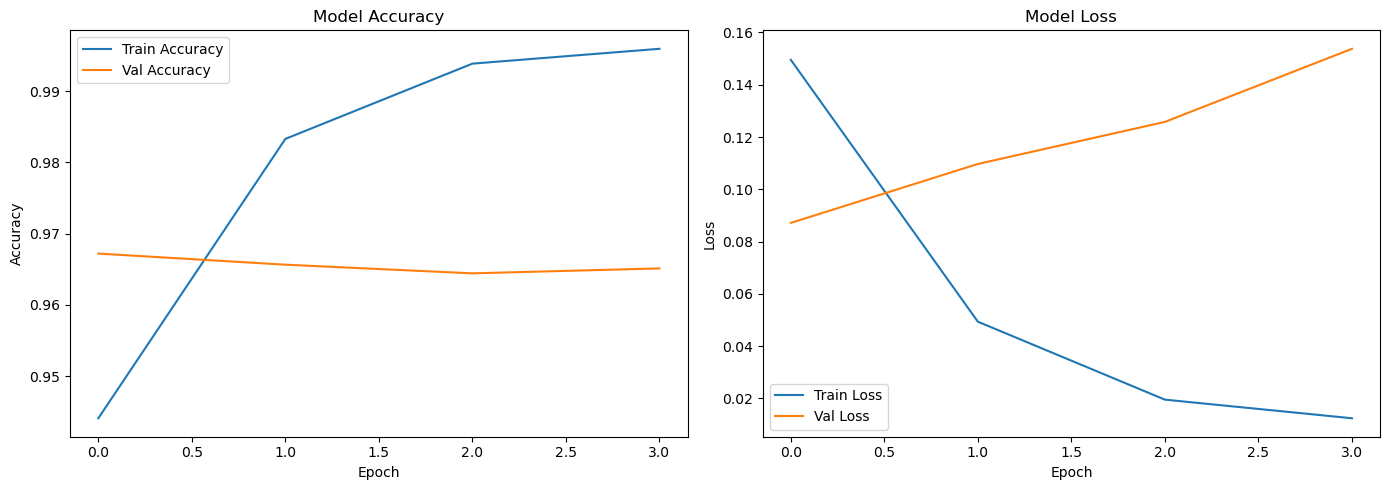

Training curves saved!


In [6]:
# Plot accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/bilstm_training_curves.png')
plt.show()
print("Training curves saved!")

451/451 ━━━━━━━━━━━━━━━━━━━━ 36s 75ms/step
  BiLSTM Model Results
  Accuracy  : 0.9681
  Precision : 0.9599
  Recall    : 0.9799
  F1-Score  : 0.9698

Classification Report:
              precision    recall  f1-score   support

        Real       0.98      0.96      0.97      6881
        Fake       0.96      0.98      0.97      7526

    accuracy                           0.97     14407
   macro avg       0.97      0.97      0.97     14407
weighted avg       0.97      0.97      0.97     14407



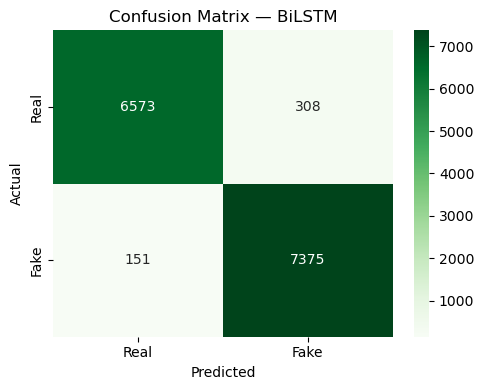


       FULL COMPARISON TABLE
              Model  Accuracy  Precision  Recall     F1
Logistic Regression    0.9643     0.9639  0.9678 0.9659
        Naive Bayes    0.8815     0.8751  0.9019 0.8883
                SVM    0.9766     0.9743  0.9811 0.9777
             BiLSTM    0.9681     0.9599  0.9799 0.9698

Full comparison saved → models/full_comparison.csv


In [7]:
# Evaluate on test data
y_pred_prob = model_bilstm.predict(X_test_pad)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

acc  = accuracy_score(y_test_arr, y_pred)
prec = precision_score(y_test_arr, y_pred)
rec  = recall_score(y_test_arr, y_pred)
f1   = f1_score(y_test_arr, y_pred)

print("="*45)
print("  BiLSTM Model Results")
print("="*45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_arr, y_pred, 
                            target_names=['Real', 'Fake']))

# Confusion Matrix
cm = confusion_matrix(y_test_arr, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix — BiLSTM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../models/BiLSTM_confusion.png')
plt.show()

# Comparison with ML models
print("\n" + "="*55)
print("       FULL COMPARISON TABLE")
print("="*55)
comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': 0.9643, 
     'Precision': 0.9639, 'Recall': 0.9678, 'F1': 0.9659},
    {'Model': 'Naive Bayes',         'Accuracy': 0.8815, 
     'Precision': 0.8751, 'Recall': 0.9019, 'F1': 0.8883},
    {'Model': 'SVM',                 'Accuracy': 0.9766, 
     'Precision': 0.9743, 'Recall': 0.9811, 'F1': 0.9777},
    {'Model': 'BiLSTM',              'Accuracy': round(acc, 4),  
     'Precision': round(prec, 4), 'Recall': round(rec, 4), 
     'F1': round(f1, 4)},
])
print(comparison.to_string(index=False))
comparison.to_csv('../models/full_comparison.csv', index=False)
print("\nFull comparison saved → models/full_comparison.csv")